In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import func_notebook as nbk
from pathlib import Path
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

In [4]:
#filepaths for cold run ALPINE
filepaths = ['/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.5Vamp-2+3sipm+54temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Vamp-2+3sipm+54temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.5Vamp-2+3sipm+56temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Vamp-2+3sipm+56temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.45Vamp-2+3sipm+56temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.45Vamp-2+3sipm+56temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.45Vamp-2+3sipm+58temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.45Vamp-2+3sipm+58temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.56Vamp-2+3sipm+52temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.56Vamp-2+3sipm+52temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/led2.56Vamp-2+3sipm+54temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.56Vamp-2+3sipm+54temp-90c.CSV',
             '/disk/gfs_atp/hekinc/Master_measurements/alpine_cold/maybe_bad_data_led2.5Va,p-2+3sipm+48temp-90c/RAW/DataR_CH0@DT5730S_63863_led2.5Va,p-2+3sipm+48temp-90c.CSV'
]


In [5]:
#array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[0], 250000000)

#nbk.plotter(array_area, array_sigma, array_bkg)

Total events: 120052
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 4886
Rejected by bad window length: 0
Successfully integrated: 115166


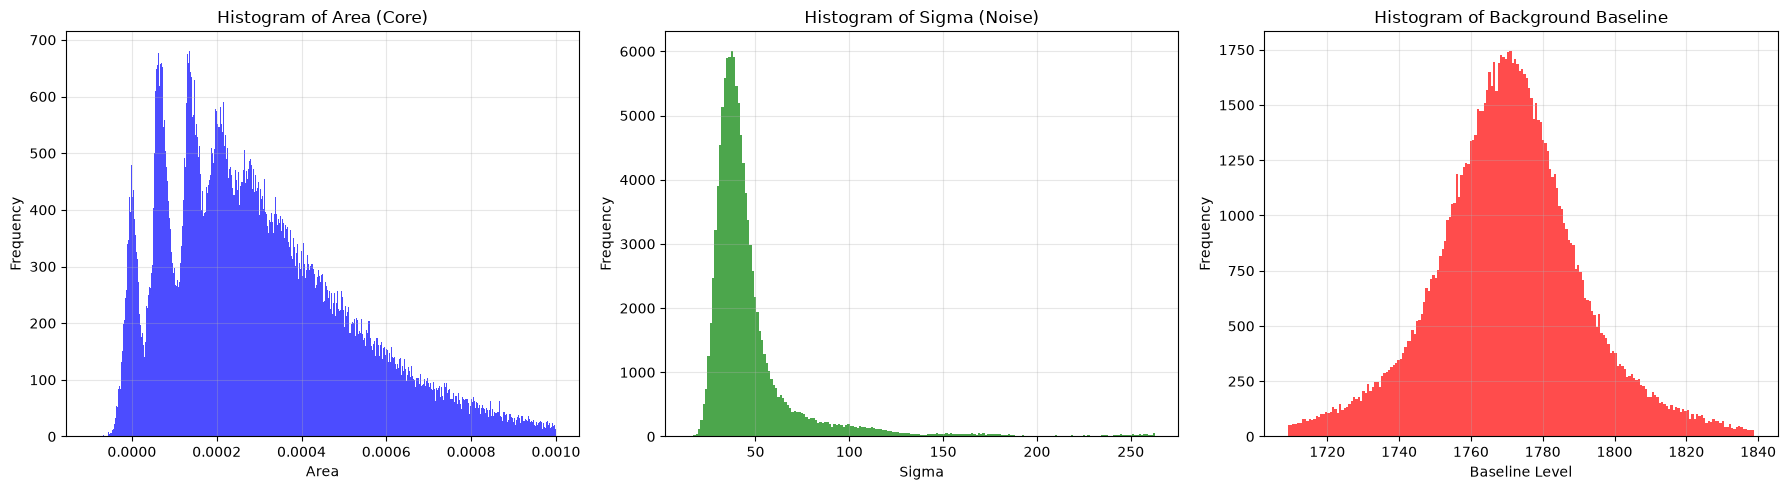

In [6]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[1], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

Processing 115166 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): -1.098017e-06
Detector Gain:      6.904642e-05
Pedestal Noise (σ_0): 1.459536e-05
1-Photon Noise (σ_1): 1.188727e-05
----------------------------
Peak 0: μ = -1.098017e-06, σ = 1.459536e-05
Peak 1: μ = 6.794840e-05, σ = 1.882370e-05
Peak 2: μ = 1.369948e-04, σ = 2.226295e-05
Peak 3: μ = 2.060412e-04, σ = 2.523780e-05
Peak 4: μ = 2.750877e-04, σ = 2.789720e-05
Peak 5: μ = 3.441341e-04, σ = 3.032426e-05
Peak 6: μ = 4.131805e-04, σ = 3.257097e-05
Peak 7: μ = 4.822269e-04, σ = 3.467240e-05
Peak 8: μ = 5.512734e-04, σ = 3.665355e-05
Peak 9: μ = 6.203198e-04, σ = 3.853298e-05
Peak 10: μ = 6.893662e-04, σ = 4.032490e-05
Peak 11: μ = 7.584126e-04, σ = 4.204051e-05
Peak 12: μ = 8.274590e-04, σ = 4.368881e-05
Peak 13: μ = 8.965055e-04, σ = 4.527714e-05
Peak 14: μ = 9.655519e-04, σ = 4.681161e-05
Peak 15: μ = 1.034598e-03, σ = 4.829735e-05
Peak 16: μ = 1.103645e-03, σ = 4.9

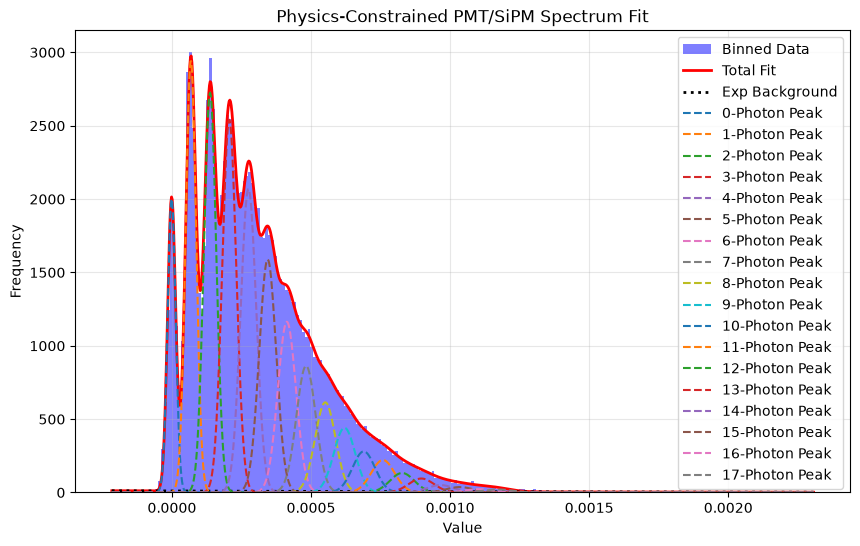

(array([ 1.03299368e+01,  6.72131835e+02, -1.09801707e-06,  1.45953606e-05,
         6.90464211e-05,  1.18872746e-05,  2.00185604e+03,  2.94524112e+03,
         2.72515140e+03,  2.54127825e+03,  2.06976144e+03,  1.58823313e+03,
         1.16383390e+03,  8.63165780e+02,  6.14302143e+02,  4.40837993e+02,
         2.80082748e+02,  2.21351728e+02,  1.32899527e+02,  9.52796504e+01,
         5.07374115e+01,  3.69836748e+01,  2.29929332e+01,  2.06546271e+01]),
 array([[ 1.10921282e+02,  5.12200529e+03,  2.14345130e-07,
         -7.60828931e-07, -8.99954609e-08,  2.10245117e-07,
         -9.59694791e+01, -8.92828243e+01, -8.71292264e+01,
         -8.38500326e+01, -7.77204949e+01, -6.98108048e+01,
         -6.14379166e+01, -5.32564584e+01, -4.60974527e+01,
         -3.92330713e+01, -3.40918559e+01, -2.96451299e+01,
         -2.43218716e+01, -2.35298805e+01, -1.52236683e+01,
         -2.25882762e+01, -3.79606080e+00, -2.58192379e+01],
        [ 5.12200529e+03,  1.11490735e+06,  1.07669219e-05,
 

In [7]:
nbk.analyze_and_fit_physics(array_area, bins=250,num_peaks_to_fit=18)

Total events: 120052
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 2052
Rejected by bad window length: 0
Successfully integrated: 118000


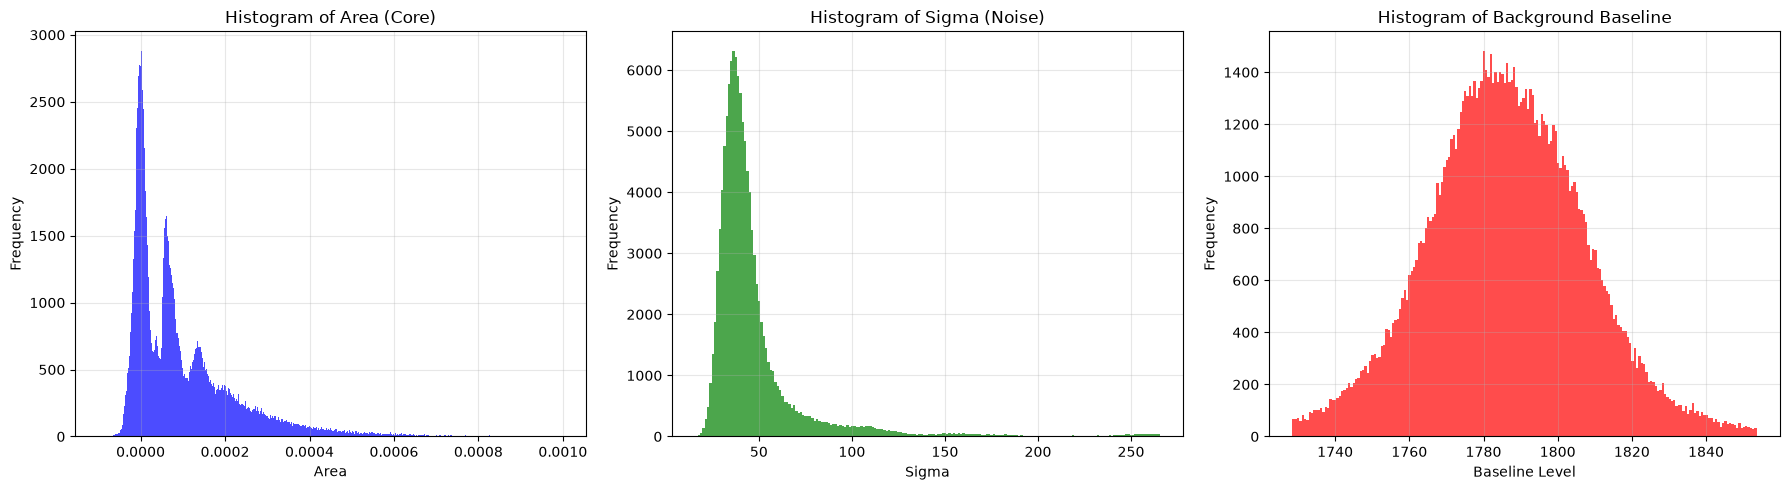

Processing 118000 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): -6.063625e-07
Detector Gain:      6.606897e-05
Pedestal Noise (σ_0): 1.467091e-05
1-Photon Noise (σ_1): 1.199549e-05
----------------------------
Peak 0: μ = -6.063625e-07, σ = 1.467091e-05
Peak 1: μ = 6.546261e-05, σ = 1.895066e-05
Peak 2: μ = 1.315316e-04, σ = 2.242809e-05
Peak 3: μ = 1.976006e-04, σ = 2.543445e-05
Peak 4: μ = 2.636695e-04, σ = 2.812122e-05
Peak 5: μ = 3.297385e-04, σ = 3.057278e-05
Peak 6: μ = 3.958075e-04, σ = 3.284184e-05
Peak 7: μ = 4.618765e-04, σ = 3.496395e-05
Peak 8: μ = 5.279454e-04, σ = 3.696444e-05


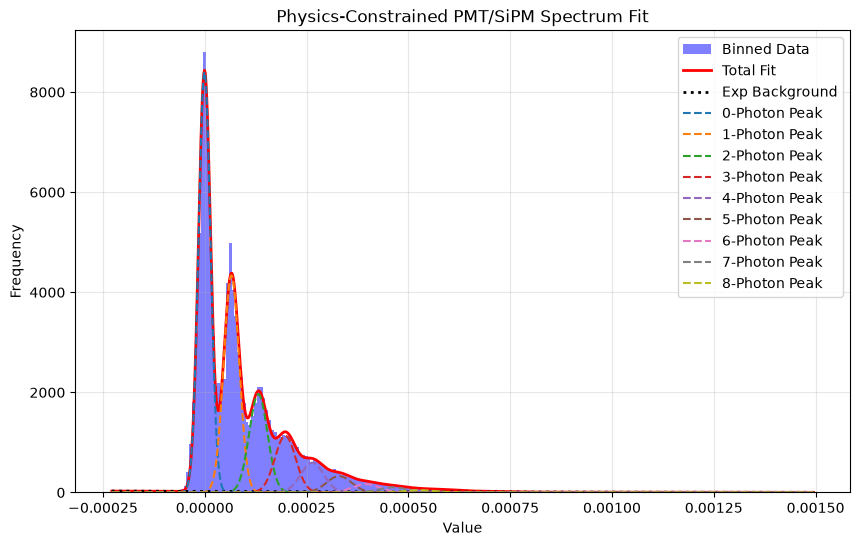

(array([ 2.11654121e+01,  1.23816203e+03, -6.06362465e-07,  1.46709148e-05,
         6.60689743e-05,  1.19954895e-05,  8.40527255e+03,  4.33934030e+03,
         1.96441936e+03,  1.13258397e+03,  5.95560008e+02,  3.27433392e+02,
         1.67921212e+02,  1.01793720e+02,  4.61413199e+01,  3.67580981e+01,
         9.38454629e+00,  1.02698110e+01]),
 array([[ 2.48080601e+02,  1.92124775e+03,  1.27808712e-07,
         -4.58616290e-07, -4.03878113e-09, -2.09747355e-07,
         -1.98716355e+02, -2.13431595e+02, -1.95412223e+02,
         -1.71859577e+02, -1.47994369e+02, -1.28666163e+02,
         -1.09785666e+02, -9.82305313e+01, -7.75275812e+01,
         -8.47711925e+01, -3.75617667e+01, -1.00188025e+02],
        [ 1.92124775e+03,  2.98760583e+06,  3.54853463e-06,
         -6.43753486e-06,  6.93863271e-07,  1.92097720e-05,
         -1.15034885e+03,  1.47099937e+03,  4.81764939e+03,
          7.48697490e+03,  9.25278607e+03,  1.05153487e+04,
          1.09404682e+04,  1.19931116e+04,  1.03632

In [9]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[2], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250)



Total events: 120065
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 3224
Rejected by bad window length: 0
Successfully integrated: 116841


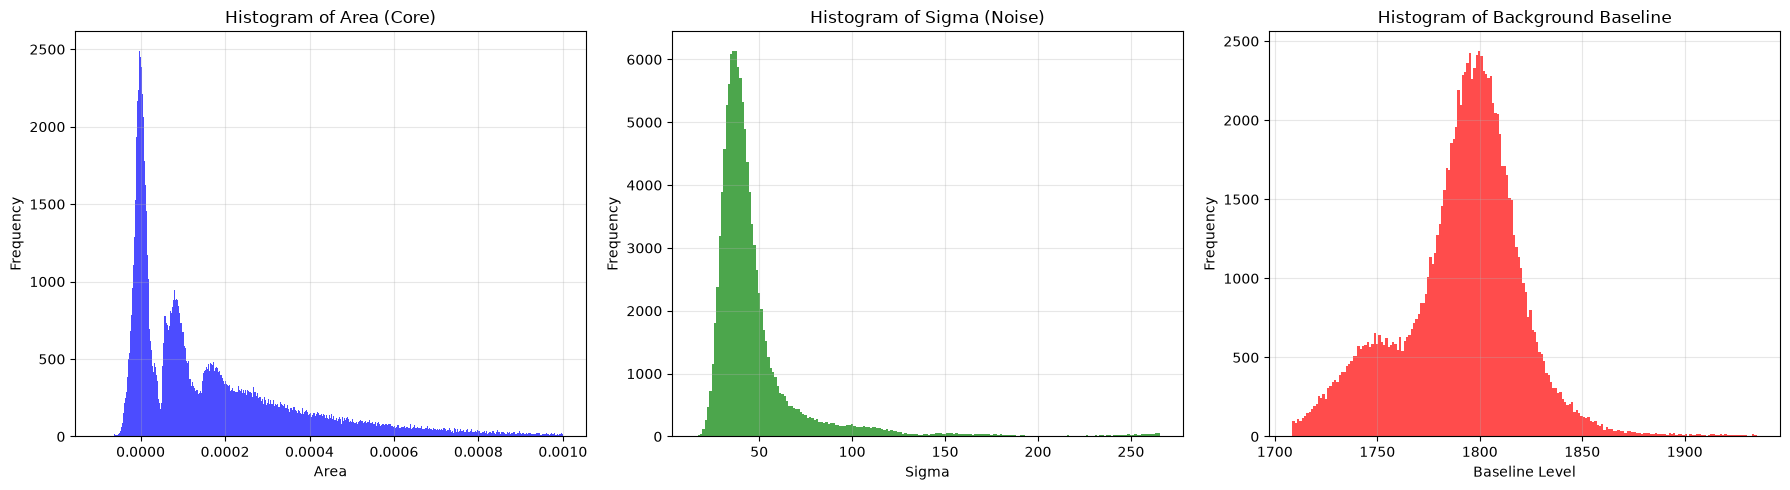

Processing 116841 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): -6.518865e-07
Detector Gain:      8.112340e-05
Pedestal Noise (σ_0): 1.541776e-05
1-Photon Noise (σ_1): 1.817366e-05
----------------------------
Peak 0: μ = -6.518865e-07, σ = 1.541776e-05
Peak 1: μ = 8.047152e-05, σ = 2.383253e-05
Peak 2: μ = 1.615949e-04, σ = 2.997117e-05
Peak 3: μ = 2.427183e-04, σ = 3.505072e-05
Peak 4: μ = 3.238417e-04, σ = 3.948208e-05
Peak 5: μ = 4.049651e-04, σ = 4.346397e-05
Peak 6: μ = 4.860885e-04, σ = 4.711049e-05
Peak 7: μ = 5.672119e-04, σ = 5.049436e-05
Peak 8: μ = 6.483353e-04, σ = 5.366528e-05
Peak 9: μ = 7.294587e-04, σ = 5.665902e-05
Peak 10: μ = 8.105821e-04, σ = 5.950232e-05
Peak 11: μ = 8.917055e-04, σ = 6.221582e-05


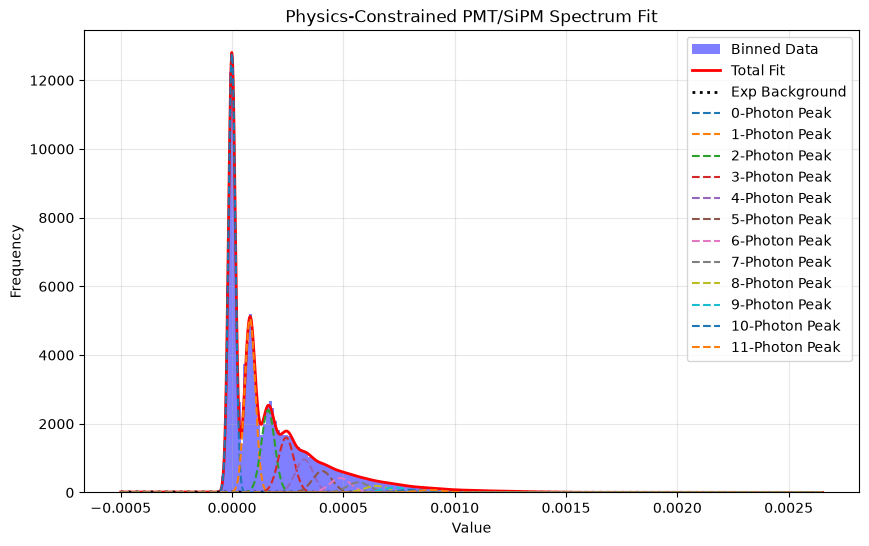

(array([ 1.09096404e+01,  4.67357228e+02, -6.51886486e-07,  1.54177646e-05,
         8.11234032e-05,  1.81736584e-05,  1.27914617e+04,  5.05311624e+03,
         2.40061158e+03,  1.60089859e+03,  9.62607262e+02,  6.23260634e+02,
         4.20175047e+02,  2.93933832e+02,  1.91781415e+02,  1.44599671e+02,
         8.01769055e+01,  7.09159832e+01,  3.35446457e+01,  3.24476056e+01,
         1.68563285e+01,  2.08871085e+01,  1.08543897e+00,  1.20136207e+01]),
 array([[ 1.40291952e+02,  2.77667289e+03,  4.17106558e-08,
         -1.88188994e-07,  1.24645076e-07, -2.15803559e-07,
         -1.08987773e+02, -1.22691307e+02, -1.05190114e+02,
         -9.20834431e+01, -8.12865771e+01, -7.25075640e+01,
         -6.40288550e+01, -5.86337571e+01, -5.04207789e+01,
         -4.97499937e+01, -3.75131936e+01, -4.70213368e+01,
         -2.02261952e+01, -5.60629626e+01,  9.62220148e+00,
         -8.14307044e+01,  4.31840573e+01, -8.13916336e+01],
        [ 2.77667289e+03,  1.21786310e+06,  1.20517808e-06,
 

In [15]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[3], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250,num_peaks_to_fit=18)


Total events: 120058
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 32395
Rejected by bad window length: 0
Successfully integrated: 87663


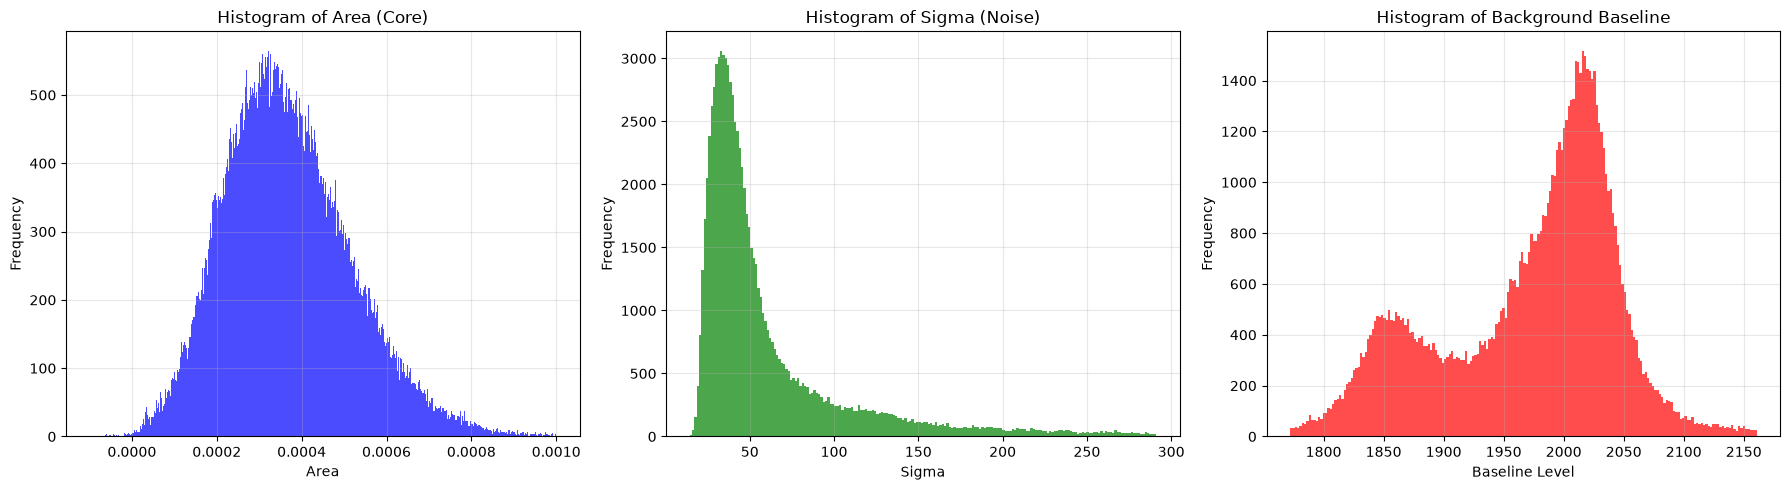

Processing 87663 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 3.104870e-04
Detector Gain:      9.958450e-05
Pedestal Noise (σ_0): 1.118765e-05
1-Photon Noise (σ_1): 4.778104e-06
----------------------------
Peak 0: μ = 3.104870e-04, σ = 1.118765e-05
Peak 1: μ = 4.100715e-04, σ = 1.216527e-05
Peak 2: μ = 5.096560e-04, σ = 1.306996e-05
Peak 3: μ = 6.092405e-04, σ = 1.391597e-05
Peak 4: μ = 7.088250e-04, σ = 1.471341e-05
Peak 5: μ = 8.084095e-04, σ = 1.546980e-05
Peak 6: μ = 9.079940e-04, σ = 1.619089e-05


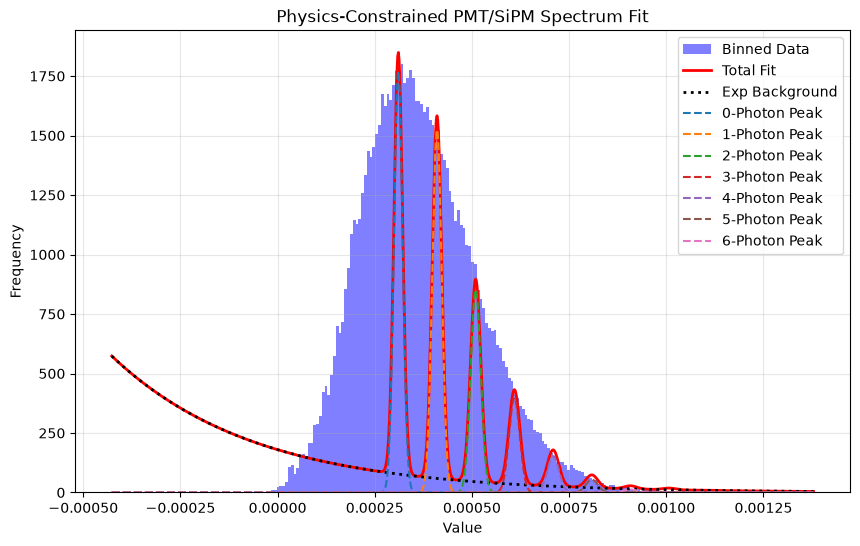

(array([1.79900000e+02, 2.71743313e+03, 3.10486963e-04, 1.11876461e-05,
        9.95845038e-05, 4.77810369e-06, 1.77200000e+03, 1.52400000e+03,
        8.52000000e+02, 3.98000000e+02, 1.53000000e+02, 5.40000000e+01,
        1.30000000e+01, 7.00000000e+00, 1.00000000e+00, 1.00000000e-10,
        1.00000000e-10, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09,
        1.00000000e-09, 1.00000000e-09, 1.00000000e-09, 1.00000000e-09]),
 array([[ 4.29478789e+03, -6.64198663e+04,  5.67225045e-07,
         -2.56968633e-05,  1.08020195e-06, -5.29732217e-05,
         -2.83570813e+03, -1.48318436e+03, -1.69704031e+03,
         -2.05075615e+03, -2.17122400e+03, -2.01881986e+03,
         -1.77173386e+03, -1.46937451e+03, -1.21933037e+03,
         -9.96132700e+02, -8.06454070e+02, -1.86898597e+03,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-6.64198663e+04,  1.43839998e+06, -7.00006029e-06,
          4.65150273e-04,

In [16]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[4], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250,num_peaks_to_fit=18)

Total events: 120092
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 21887
Rejected by bad window length: 0
Successfully integrated: 98205


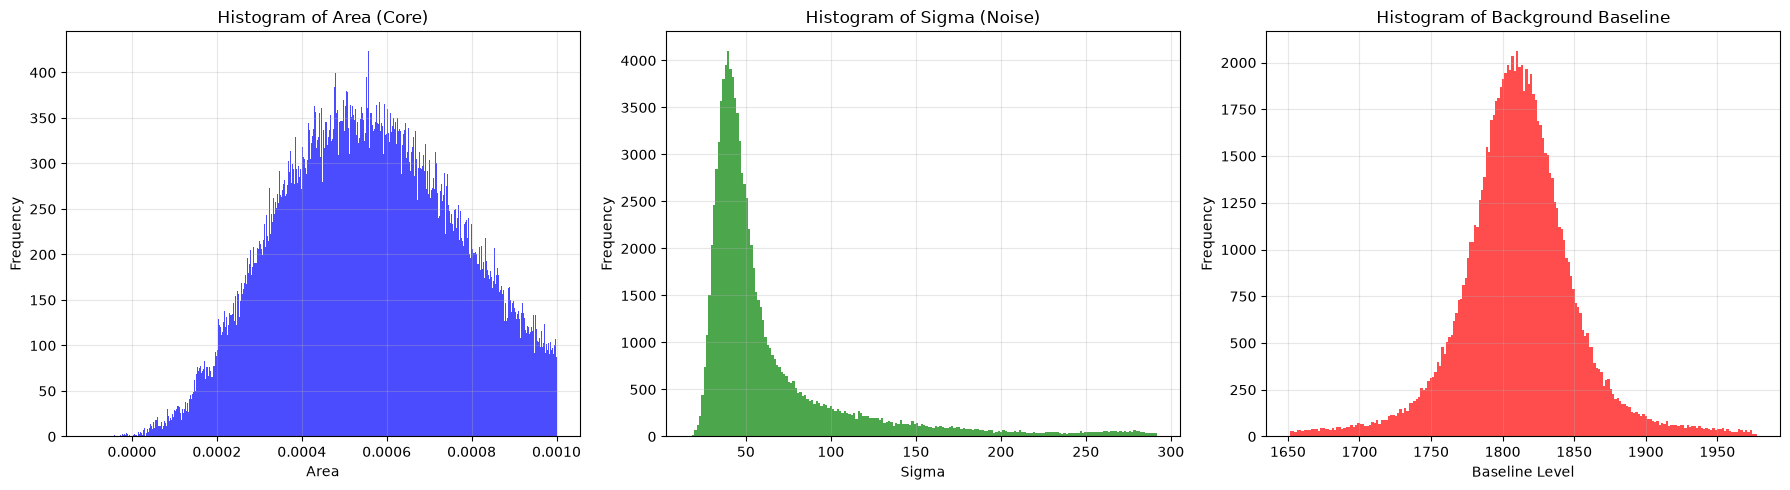

Processing 98205 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 2.328074e-04
Detector Gain:      7.349447e-05
Pedestal Noise (σ_0): 2.399869e-05
1-Photon Noise (σ_1): 2.390835e-05
----------------------------
Peak 0: μ = 2.328074e-04, σ = 2.399869e-05
Peak 1: μ = 3.063019e-04, σ = 3.387545e-05
Peak 2: μ = 3.797964e-04, σ = 4.146269e-05
Peak 3: μ = 4.532908e-04, σ = 4.786193e-05
Peak 4: μ = 5.267853e-04, σ = 5.350115e-05
Peak 5: μ = 6.002798e-04, σ = 5.860019e-05
Peak 6: μ = 6.737743e-04, σ = 6.328974e-05
Peak 7: μ = 7.472687e-04, σ = 6.765501e-05
Peak 8: μ = 8.207632e-04, σ = 7.175520e-05
Peak 9: μ = 8.942577e-04, σ = 7.563345e-05
Peak 10: μ = 9.677522e-04, σ = 7.932230e-05
Peak 11: μ = 1.041247e-03, σ = 8.284706e-05


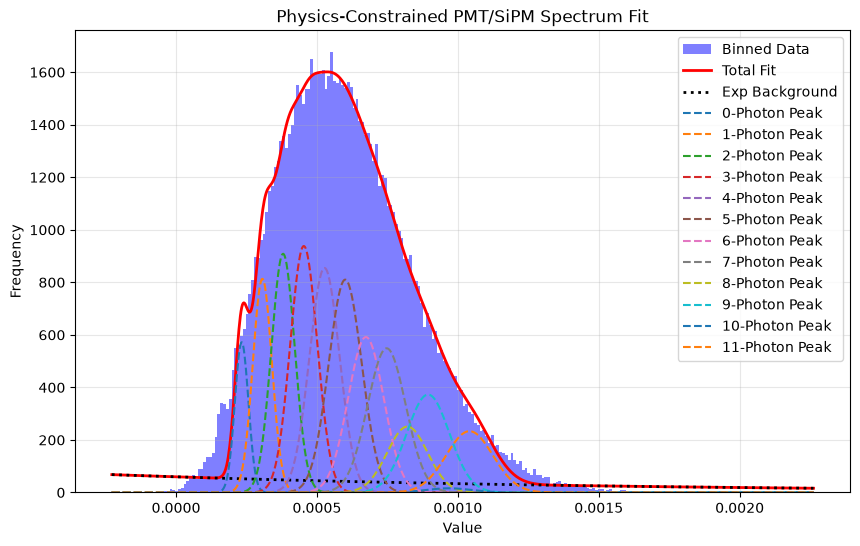

(array([5.96796271e+01, 5.76692976e+02, 2.32807411e-04, 2.39986890e-05,
        7.34944745e-05, 2.39083457e-05, 5.72199586e+02, 8.13474815e+02,
        9.08819942e+02, 9.38395669e+02, 8.54805353e+02, 8.10371935e+02,
        5.91651646e+02, 5.48971091e+02, 2.50980689e+02, 3.72801290e+02,
        1.60377459e+01, 2.33409253e+02]),
 array([[ 6.45034028e+01,  5.74007194e+02,  7.96793687e-07,
         -2.07303212e-06, -1.95993415e-06,  1.08402611e-06,
         -3.40294457e+01, -5.19042320e+01, -6.90992705e+01,
         -6.04797613e+01, -6.81399065e+01, -3.05604267e+01,
         -5.17934029e+01,  2.09927789e+01, -6.06275970e+01,
          5.97112852e+01, -6.22232778e+01,  3.93045338e+01],
        [ 5.74007194e+02,  2.49799342e+04, -2.33534717e-05,
         -2.45546963e-05, -2.93512560e-06,  7.34559547e-05,
         -5.40309023e+02, -1.16651644e+03, -1.83770067e+03,
         -1.79001612e+03, -2.03884283e+03, -1.26629906e+03,
         -1.80779786e+03, -1.28811115e+02, -1.89502064e+03,
         

In [12]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[5], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250)

Total events: 120061
Rejected by High Noise: 0
Rejected by Pile-up (Found >1 peak): 32078
Rejected by bad window length: 0
Successfully integrated: 87983


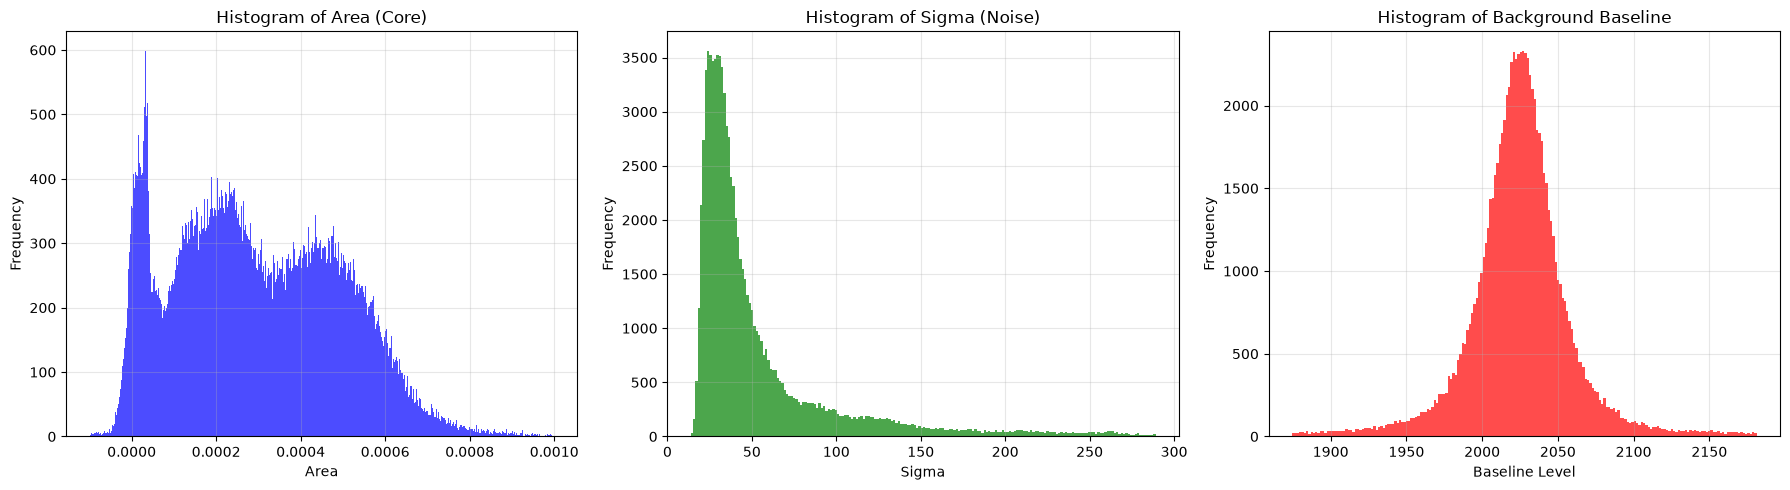

Processing 87983 data points...
Physics Curve fitting converged successfully!

--- Physical Fit Results ---
Pedestal (μ_0): 3.033827e-05
Detector Gain:      2.011156e-04
Pedestal Noise (σ_0): 1.429121e-05
1-Photon Noise (σ_1): 7.810669e-06
----------------------------
Peak 0: μ = 3.033827e-05, σ = 1.429121e-05
Peak 1: μ = 2.314539e-04, σ = 1.628635e-05
Peak 2: μ = 4.325695e-04, σ = 1.806244e-05
Peak 3: μ = 6.336852e-04, σ = 1.967888e-05


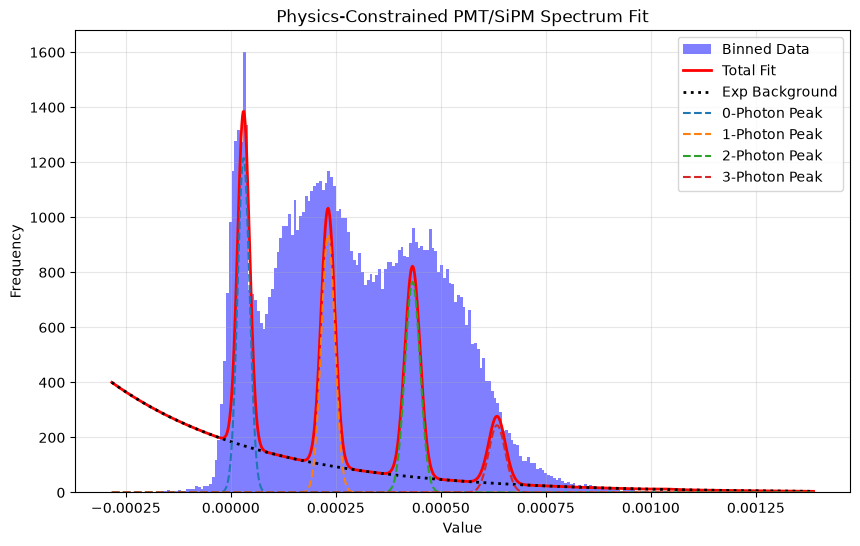

(array([1.84767276e+02, 2.72749835e+03, 3.03382690e-05, 1.42912106e-05,
        2.01115636e-04, 7.81066870e-06, 1.21633260e+03, 9.34912785e+02,
        7.65521970e+02, 2.44375545e+02, 3.85973068e-02, 1.59822191e+00,
        5.78354860e-11, 1.00000021e-09, 1.00000000e-09, 1.00000000e-09,
        1.00000000e-09, 1.00000000e-09]),
 array([[ 2.77650968e+03, -4.75075700e+04, -2.96018561e-07,
         -4.55160122e-05,  2.17398640e-06, -4.80637221e-05,
         -2.02265891e+03, -1.80791036e+03, -1.21321403e+03,
         -1.53426245e+03, -1.46690457e+03, -9.92005063e+02,
         -6.61218127e+02, -3.97314754e+03,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [-4.75075700e+04,  1.89043042e+06,  8.59566797e-05,
          8.49687124e-04, -8.72064315e-05,  1.94539046e-03,
          3.93217105e+04,  4.82753963e+04,  3.63871139e+04,
          4.93063208e+04,  4.92189662e+04,  3.42039238e+04,
          2.32542934e+04,  1.41299948e+05,  0.00000000e+00,
         

In [13]:
array_area, array_sigma, array_bkg = nbk.compute_DAQ_data(filepaths[6], 250000000)

nbk.plotter(array_area, array_sigma, array_bkg)

nbk.analyze_and_fit_physics(array_area, bins=250)